# Build-Time Analysis Across Library Commits

This notebook analyzes `library-build-times.csv`, which records build attempts for recent commits of the studied libraries.

The notebook has three goals:

- validate the structure and coverage of the CSV that is actually present in the repository;
- compute per-library success and failure rates for the observed commit windows;
- summarize average build times per library, both across all attempts and across successful builds only.


In [1]:
from pathlib import Path
from textwrap import shorten

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = Path("library-build-times.csv")
OUTPUT_PDF_PATH = Path("figures/")
EXPECTED_OUTCOMES = {"success", "build_failed"}

In [2]:
required_columns = {
    "timestamp_utc",
    "repo_name",
    "repo_path",
    "default_ref",
    "commit_index",
    "commit",
    "commit_subject",
    "build_tool",
    "build_command",
    "elapsed_seconds",
    "exit_code",
    "outcome",
    "message",
}

df = pd.read_csv(DATA_PATH)
missing_columns = sorted(required_columns - set(df.columns))
assert not missing_columns, f"Missing columns: {missing_columns}"

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
df["elapsed_seconds"] = pd.to_numeric(df["elapsed_seconds"], errors="coerce")
df["exit_code"] = pd.to_numeric(df["exit_code"], errors="coerce")
df["library"] = df["repo_name"].str.replace("__", "/", regex=False)
df["is_success"] = df["outcome"].eq("success")
df["is_failure"] = ~df["is_success"]

display(df.head())


,timestamp_utc,repo_name,repo_path,default_ref,commit_index,commit,commit_subject,build_tool,build_command,elapsed_seconds,exit_code,outcome,message,library,is_success,is_failure
0,2026-03-29 09:19:28.071881+00:00,FasterXML__jackson-core,FasterXML__jackson-core,refs/remotes/origin/3.x,1,6dbf54186b36f116f426cb60373cab53cfd9a36d,Merge branch '3.1' into 3.x,maven,sh ./mvnw -B clean package -DskipTests -Dmaven...,11.141121,0,success,NaN,FasterXML/jackson-core,True,False
1,2026-03-29 09:19:33.431146+00:00,FasterXML__jackson-core,FasterXML__jackson-core,refs/remotes/origin/3.x,2,2a0054aead585f616238d1df6a70972f72277711,Add `NonBlockingByteBufferParser` tests for JS...,maven,sh ./mvnw -B clean package -DskipTests -Dmaven...,5.312209,0,success,NaN,FasterXML/jackson-core,True,False
2,2026-03-29 09:19:38.727631+00:00,FasterXML__jackson-core,FasterXML__jackson-core,refs/remotes/origin/3.x,3,f97baf9d78883c818748e9eb2f1df169c4693f55,Trigger 3.x cascading publish,maven,sh ./mvnw -B clean package -DskipTests -Dmaven...,5.271898,0,success,NaN,FasterXML/jackson-core,True,False
3,2026-03-29 09:19:43.980040+00:00,FasterXML__jackson-core,FasterXML__jackson-core,refs/remotes/origin/3.x,4,c53454a55c2e8f6642459378befaf7fe28050f1d,Add `JsonParser.willInternPropertyNames()` for...,maven,sh ./mvnw -B clean package -DskipTests -Dmaven...,5.229235,0,success,NaN,FasterXML/jackson-core,True,False
4,2026-03-29 09:19:49.230022+00:00,FasterXML__jackson-core,FasterXML__jackson-core,refs/remotes/origin/3.x,5,701cd6af465c586aa9b33e95294acde034bd17af,Implement document length tracking for DataInp...,maven,sh ./mvnw -B clean package -DskipTests -Dmaven...,5.224596,0,success,NaN,FasterXML/jackson-core,True,False


## Dataset Validation

The notebook validates the file that is present in the repository rather than assuming perfect 32-library coverage. In particular, it checks schema completeness, duplicate `(repo_name, commit)` pairs, outcome labels, and how many build attempts are available for each library.


In [3]:
commit_counts = df.groupby("repo_name").size().sort_values()
duplicate_pairs = int(df.duplicated(["repo_name", "commit"]).sum())
unexpected_outcomes = sorted(set(df["outcome"].dropna()) - EXPECTED_OUTCOMES)

validation_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "libraries",
            "duplicate repo/commit pairs",
            "missing elapsed_seconds",
            "unexpected outcomes",
            "max commits observed for one library",
            "libraries with 50 commits",
            "libraries with fewer than 50 commits",
        ],
        "value": [
            len(df),
            df["repo_name"].nunique(),
            duplicate_pairs,
            int(df["elapsed_seconds"].isna().sum()),
            len(unexpected_outcomes),
            int(commit_counts.max()),
            int((commit_counts == 50).sum()),
            int((commit_counts < 50).sum()),
        ],
    }
)

display(validation_summary)

assert duplicate_pairs == 0, "Found duplicate (repo_name, commit) pairs"
assert df["elapsed_seconds"].notna().all(), "Some rows have missing elapsed_seconds values"
assert not unexpected_outcomes, f"Unexpected outcomes found: {unexpected_outcomes}"
assert (commit_counts <= 50).all(), "Some libraries expose more than 50 build attempts"

coverage_gaps = commit_counts[commit_counts < 50].rename("commits_observed").to_frame()
if coverage_gaps.empty:
    display(Markdown("All libraries expose the full 50-commit window in this CSV."))
else:
    display(Markdown("Libraries with fewer than 50 observed build attempts:"))
    display(coverage_gaps)


,metric,value
0,rows,1300
1,libraries,26
2,duplicate repo/commit pairs,0
3,missing elapsed_seconds,0
4,unexpected outcomes,0
5,max commits observed for one library,50
6,libraries with 50 commits,26
7,libraries with fewer than 50 commits,0


All libraries expose the full 50-commit window in this CSV.

## Overall Reliability

Before drilling into individual libraries, it is useful to establish the aggregate success and failure volume represented in the CSV.


In [4]:
overall_summary = pd.DataFrame(
    {
        "metric": [
            "successful builds",
            "failed builds",
            "overall success rate (%)",
            "overall failure rate (%)",
            "mean elapsed time across all attempts (s)",
            "median elapsed time across all attempts (s)",
        ],
        "value": [
            int(df["is_success"].sum()),
            int(df["is_failure"].sum()),
            round(100 * df["is_success"].mean(), 2),
            round(100 * df["is_failure"].mean(), 2),
            round(df["elapsed_seconds"].mean(), 2),
            round(df["elapsed_seconds"].median(), 2),
        ],
    }
)

display(overall_summary)
display(df["build_tool"].value_counts().rename_axis("build_tool").reset_index(name="builds"))


,metric,value
0,successful builds,1241.00
1,failed builds,59.00
2,overall success rate (%),95.46
3,overall failure rate (%),4.54
4,mean elapsed time across all attempts (s),26.12
5,median elapsed time across all attempts (s),11.62


,build_tool,builds
0,maven,950
1,gradle,300
2,ant,50


## Per-Library Success Rates and Build Times

The table below reports the observed commit coverage, success and failure counts, and average elapsed time per library. The notebook keeps both `avg_elapsed_seconds` and `avg_success_elapsed_seconds` because failed builds still consume time and therefore affect throughput, but the success-only metric isolates the cost of builds that actually produce an artifact.


In [5]:
per_library = (
    df.groupby(["repo_name", "library"], as_index=False)
    .agg(
        commits_observed=("commit", "size"),
        successes=("is_success", "sum"),
        failures=("is_failure", "sum"),
        success_rate=("is_success", "mean"),
        avg_elapsed_seconds=("elapsed_seconds", "mean"),
        median_elapsed_seconds=("elapsed_seconds", "median"),
        avg_success_elapsed_seconds=(
            "elapsed_seconds",
            lambda s: s[df.loc[s.index, "is_success"]].mean(),
        ),
        build_tool=("build_tool", lambda s: s.mode().iat[0]),
    )
    .sort_values(["success_rate", "avg_elapsed_seconds"], ascending=[True, False])
    .reset_index(drop=True)
)

per_library["failure_rate"] = 1.0 - per_library["success_rate"]
per_library["success_rate_pct"] = 100 * per_library["success_rate"]
per_library["failure_rate_pct"] = 100 * per_library["failure_rate"]

display(
    per_library[
        [
            "library",
            "build_tool",
            "commits_observed",
            "successes",
            "failures",
            "success_rate_pct",
            "failure_rate_pct",
            "avg_elapsed_seconds",
            "avg_success_elapsed_seconds",
            "median_elapsed_seconds",
        ]
    ].round(2)
)


,library,build_tool,commits_observed,successes,failures,success_rate_pct,failure_rate_pct,avg_elapsed_seconds,avg_success_elapsed_seconds,median_elapsed_seconds
0,google/gson,maven,50,20,30,40.0,60.0,19.55,19.65,18.96
1,osgi/osgi,gradle,50,26,24,52.0,48.0,28.35,51.77,50.42
2,projectlombok/lombok,ant,50,47,3,94.0,6.0,105.69,105.62,105.14
3,alibaba/fastjson2,maven,50,49,1,98.0,2.0,56.00,55.98,53.95
4,qos-ch/slf4j,maven,50,49,1,98.0,2.0,4.08,4.11,4.03
5,apache/logging-log4j2,maven,50,50,0,100.0,0.0,91.14,91.14,90.67
6,apache/maven,maven,50,50,0,100.0,0.0,69.65,69.65,68.91
7,google/guava,maven,50,50,0,100.0,0.0,66.92,66.92,66.13
8,testng-team/testng,gradle,50,50,0,100.0,0.0,41.81,41.81,34.80
9,spring-projects/spring-framework,gradle,50,50,0,100.0,0.0,22.15,22.15,17.30


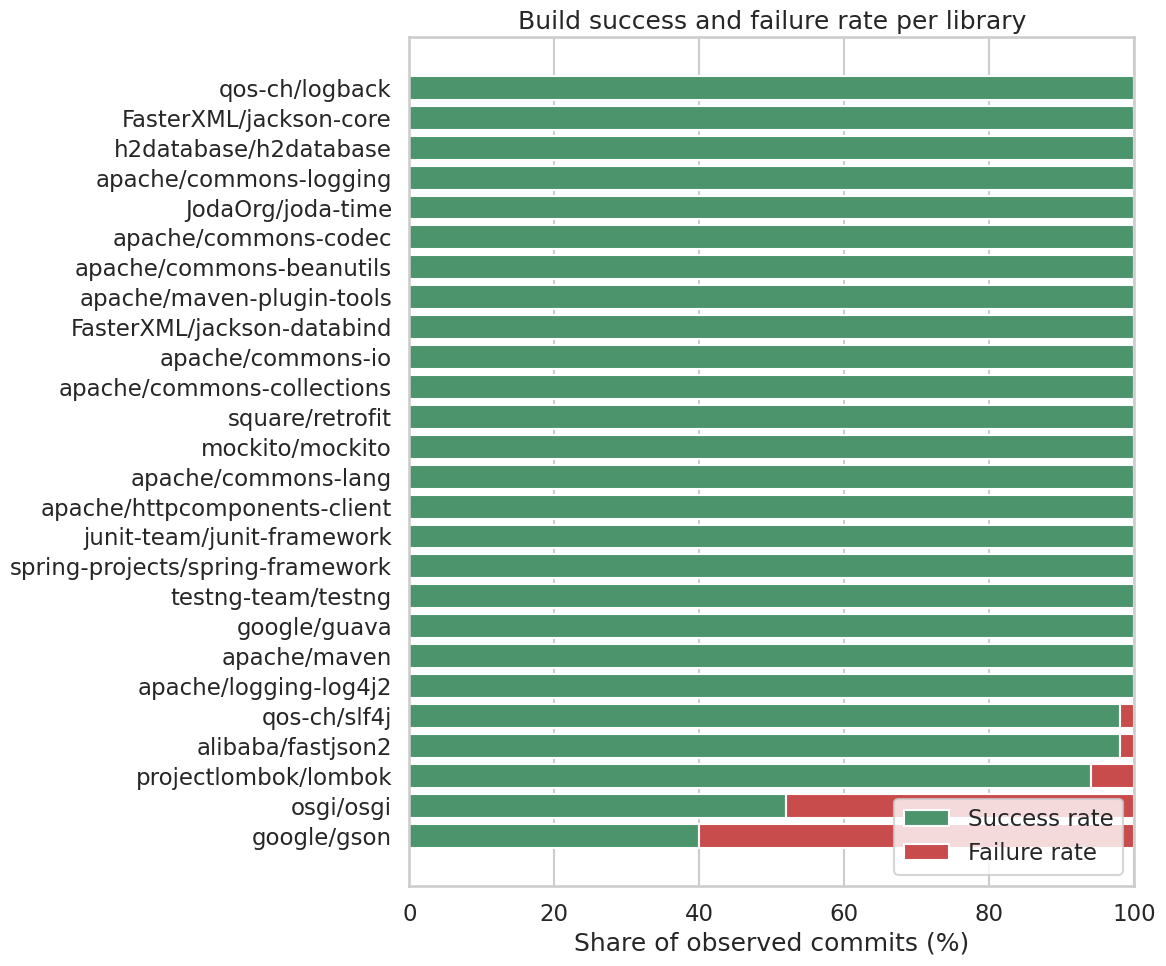

In [6]:
plot_df = per_library.sort_values("success_rate_pct")
fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(plot_df["library"], plot_df["success_rate_pct"], color="#4C956C", label="Success rate")
ax.barh(
    plot_df["library"],
    plot_df["failure_rate_pct"],
    left=plot_df["success_rate_pct"],
    color="#C94C4C",
    label="Failure rate",
)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of observed commits (%)")
ax.set_ylabel("")
ax.set_title("Build success and failure rate per library")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


Saved plot to /home/dig/repositories/emse26-roseau/results/longitudinal/walk/notebooks/figures (4096 bytes)


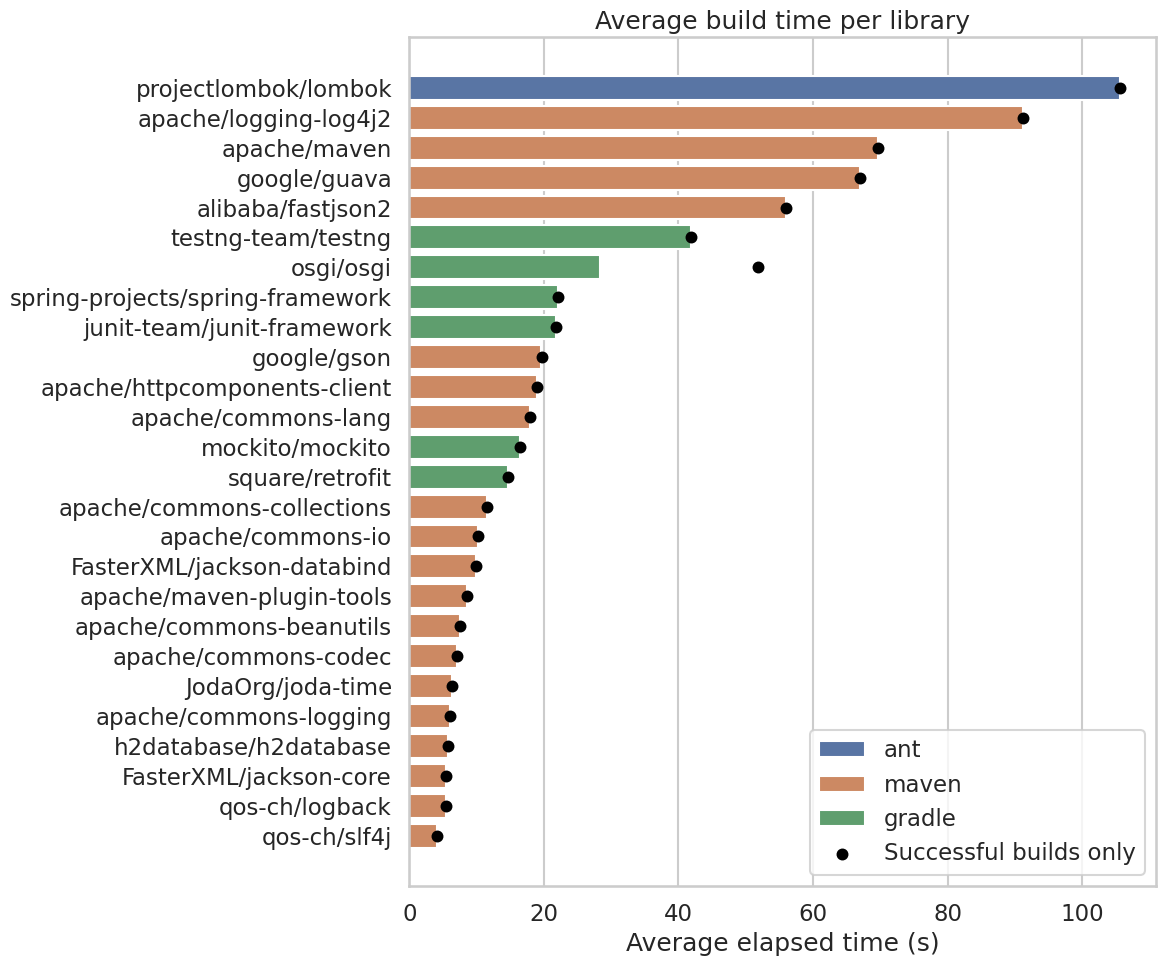

In [7]:
plot_df = per_library.sort_values("avg_elapsed_seconds", ascending=False)
fig, ax = plt.subplots(figsize=(12, 10))
sns.barplot(data=plot_df, x="avg_elapsed_seconds", y="library", hue="build_tool", dodge=False, ax=ax)
ax.scatter(
    plot_df["avg_success_elapsed_seconds"],
    ax.get_yticks(),
    color="black",
    s=50,
    label="Successful builds only",
    zorder=3,
)
ax.set_xlabel("Average elapsed time (s)")
ax.set_ylabel("")
ax.set_title("Average build time per library")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(OUTPUT_PDF_PATH / "build-times.pdf", bbox_inches="tight")
plt.show()

## Failure Diagnostics

When builds fail, the message column helps distinguish systematic incompatibilities from occasional regressions. The next table reports, for each affected library, how many failures were observed, where they occurred in the commit window, and one shortened example message.


In [8]:
failure_rows = df.loc[df["is_failure"]].copy()
failure_rows["message_short"] = failure_rows["message"].fillna("").map(
    lambda text: shorten(" ".join(text.split()), width=120, placeholder="...") if text else ""
)

failure_summary = (
    failure_rows.groupby("library", as_index=False)
    .agg(
        failures=("commit", "size"),
        first_failed_commit=("commit_index", "min"),
        last_failed_commit=("commit_index", "max"),
        sample_failure_message=(
            "message_short",
            lambda s: next((msg for msg in s if msg), ""),
        ),
    )
    .sort_values(["failures", "first_failed_commit"], ascending=[False, True])
    .reset_index(drop=True)
)

display(failure_summary)


,library,failures,first_failed_commit,last_failed_commit,sample_failure_message
0,google/gson,30,1,30,[ERROR] ====================== | [ERROR] Full ...
1,osgi/osgi,24,16,50,> Task :org.osgi.framework:jar FAILED | /data/...
2,projectlombok/lombok,3,10,50,29. ERROR in /data/tmp-build/worktrees/project...
3,qos-ch/slf4j,1,11,11,[ERROR] COMPILATION ERROR : | [ERROR] /data/tm...
4,alibaba/fastjson2,1,20,20,"[WARNING] arrow-format-17.0.0.jar, arrow-memor..."


In [9]:
perfect_builders = int((per_library["failures"] == 0).sum())
partial_coverage = per_library.loc[per_library["commits_observed"] < 50, "library"].tolist()
least_reliable = per_library.nsmallest(3, "success_rate")[["library", "success_rate_pct"]]
slowest = per_library.nlargest(3, "avg_elapsed_seconds")[["library", "avg_elapsed_seconds"]]

coverage_note = (
    f"The CSV contains fewer than 50 build attempts for {', '.join(partial_coverage)}."
    if partial_coverage
    else "All libraries expose the full 50-commit window."
)

display(
    Markdown(
        "\n".join(
            [
                "### Key observations",
                f"- The CSV contains **{len(df):,}** build attempts across **{df['repo_name'].nunique()}** libraries.",
                f"- **{perfect_builders}** libraries build successfully for every observed commit.",
                f"- {coverage_note}",
                "- The least reliable libraries in this file are "
                + ", ".join(
                    f"**{row.library}** ({row.success_rate_pct:.1f}% success)"
                    for row in least_reliable.itertuples(index=False)
                )
                + ".",
                "- The slowest libraries on average are "
                + ", ".join(
                    f"**{row.library}** ({row.avg_elapsed_seconds:.1f} s)"
                    for row in slowest.itertuples(index=False)
                )
                + ".",
            ]
        )
    )
)


### Key observations
- The CSV contains **1,300** build attempts across **26** libraries.
- **21** libraries build successfully for every observed commit.
- All libraries expose the full 50-commit window.
- The least reliable libraries in this file are **google/gson** (40.0% success), **osgi/osgi** (52.0% success), **projectlombok/lombok** (94.0% success).
- The slowest libraries on average are **projectlombok/lombok** (105.7 s), **apache/logging-log4j2** (91.1 s), **apache/maven** (69.7 s).

In [10]:
LONGITUDINAL_DATA_DIR = Path("data")

history_rows = []
for path in sorted(LONGITUDINAL_DATA_DIR.glob("*-commits.csv")):
    history = pd.read_csv(path, usecols=["library", "commit_url"], low_memory=False)
    library = (
        history["library"].dropna().iat[0]
        if history["library"].notna().any()
        else path.stem.removesuffix("-commits")
    )
    repo_parts = history["commit_url"].fillna("").astype(str).str.split("/")
    repository_slug = (repo_parts.str[3].fillna("") + "/" + repo_parts.str[4].fillna("")).mode().iat[0]
    history_rows.append(
        {
            "library": library,
            "repository_slug": repository_slug,
            "repo_name": repository_slug.replace("/", "__"),
            "commits_in_history": len(history),
        }
    )

history_commits = pd.DataFrame(history_rows)

observed_build_medians = (
    df.groupby(["repo_name", "library"], as_index=False)
    .agg(
        build_attempts=("commit", "size"),
        median_build_seconds=("elapsed_seconds", "median"),
    )
)

longitudinal_cost = (
    history_commits.merge(observed_build_medians[["repo_name", "build_attempts", "median_build_seconds"]], on="repo_name", how="inner", validate="many_to_one")
    .assign(
        estimated_history_build_seconds=lambda d: d["commits_in_history"] * d["median_build_seconds"],
        estimated_history_build_minutes=lambda d: d["estimated_history_build_seconds"] / 60,
        estimated_history_build_hours=lambda d: d["estimated_history_build_seconds"] / 3600,
    )
    .sort_values("estimated_history_build_seconds", ascending=False)
    .reset_index(drop=True)
)

excluded_libraries = sorted(set(history_commits["library"]) - set(longitudinal_cost["library"]))

display(
    longitudinal_cost[
        [
            "library",
            "repository_slug",
            "commits_in_history",
            "median_build_seconds",
            "estimated_history_build_minutes",
            "estimated_history_build_hours",
        ]
    ].round(
        {
            "median_build_seconds": 2,
            "estimated_history_build_minutes": 1,
            "estimated_history_build_hours": 2,
        }
    )
)

overall_seconds = longitudinal_cost["estimated_history_build_seconds"].sum()
overall_hours = overall_seconds / 3600
overall_days = overall_hours / 24
largest_estimates = longitudinal_cost.head(5)[["library", "estimated_history_build_hours"]]
excluded_note = (
    "- The estimate excludes longitudinal-study libraries that are absent from `library-build-times.csv`: "
    + ", ".join(f"**{library}**" for library in excluded_libraries)
    + "."
    if excluded_libraries
    else "- Every longitudinal-study library is present in `library-build-times.csv`."
)

display(
    Markdown(
        "\n".join(
            [
                "### Estimated whole-history build cost",
                "- The estimate multiplies each library's commit count in `notebooks/data/*-commits.csv` by the median repository build time observed in `library-build-times.csv`.",
                f"- Across the **{len(longitudinal_cost)}** libraries covered by `library-build-times.csv`, building every commit once is estimated to take **{overall_hours:,.1f} hours** (**{overall_days:,.1f} days**).",
                excluded_note,
                "- The largest estimated costs are "
                + ", ".join(
                    f"**{row.library}** ({row.estimated_history_build_hours:.1f} h)"
                    for row in largest_estimates.itertuples(index=False)
                )
                + ".",
            ]
        )
    )
)


,library,repository_slug,commits_in_history,median_build_seconds,estimated_history_build_minutes,estimated_history_build_hours
0,log4j-core,apache/logging-log4j2,11239,90.67,16984.0,283.07
1,log4j-api,apache/logging-log4j2,10832,90.67,16368.9,272.82
2,maven-plugin-api,apache/maven,12427,68.91,14272.2,237.87
3,org.osgi.core,osgi/osgi,12461,50.42,10472.3,174.54
4,spring-context,spring-projects/spring-framework,28160,17.30,8119.1,135.32
5,guava,google/guava,7254,66.13,7994.5,133.24
6,lombok,projectlombok/lombok,2763,105.14,4841.5,80.69
7,fastjson,alibaba/fastjson2,4613,53.95,4147.7,69.13
8,commons-lang,apache/commons-lang,8659,17.97,2593.5,43.23
9,junit-jupiter-api,junit-team/junit-framework,9924,11.76,1944.9,32.41


### Estimated whole-history build cost
- The estimate multiplies each library's commit count in `notebooks/data/*-commits.csv` by the median repository build time observed in `library-build-times.csv`.
- Across the **26** libraries covered by `library-build-times.csv`, building every commit once is estimated to take **1,642.1 hours** (**68.4 days**).
- The estimate excludes longitudinal-study libraries that are absent from `library-build-times.csv`: **assertj-core**, **mysql-connector-j**, **protobuf-java**.
- The largest estimated costs are **log4j-core** (283.1 h), **log4j-api** (272.8 h), **maven-plugin-api** (237.9 h), **org.osgi.core** (174.5 h), **spring-context** (135.3 h).